### Imports and Read CSV

In [1]:
from google.colab import files
uploaded = files.upload()

In [2]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 89.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import gurobipy as gp

### Task 1

Attached to this project are two csv files with stock price data (you need to calculate the percentage
return yourself) from 100 stocks in 2019 and 2020. We are considering 2019 – 2020 because in 2019 the
world was relatively normal and then in 2020 the covid pandemic hit and the market went a little crazy,
making this an excellent case study for the effectiveness of risk management. The NDX column is the
Nasdaq index, and the other columns consist of the stocks that make up the index – the NDX should not
be considered as part of your portfolio. You will use the data from 2019 to build a vector of portfolio
weights, x, and then see how that portfolio would have performed in 2020.


In [4]:
# Load data in
stocks2019 = pd.read_csv("stocks2019.csv")
stocks2020 = pd.read_csv("stocks2020.csv")

# Data setup
stocks2019["X"] = pd.to_datetime(stocks2019["X"])
stocks2019 = stocks2019.set_index("X")
stocks2019_clean = stocks2019.drop(columns=["NDX"])

# Calculate daily returns
daily_returns = stocks2019_clean.pct_change().dropna()
average_daily_returns = daily_returns.mean()
stock_names = daily_returns.columns.tolist()

In [5]:
# === Testing Instructions for Task 1 ===
# Uncomment the lines below to test data preparation
# print("Daily returns shape:", daily_returns.shape)
# print("First 5 rows:\n", daily_returns.head())
# print("Average daily returns:\n", average_daily_returns)

### Task 2


Find the portfolio that minimizes the daily average -CVaR using the 2019 data. Use =0.95 and
R=0.02%. If you keep using the 2019 portfolio in 2020, what is the daily average -CVaR in 2020? Is it a
good idea to stick with the same portfolio across different years? Briefly justify using the differences
between in-sample and out-of-sample daily average CVaR, and comment on potential non-stationarity.

* To calculate the cVaR using 2020 data and the 2019 portfolio you can re-evaluate 𝐹̃𝛽(𝒙) using the
x from 2019, and the y’s from 2020.
* What is the cVaR of the NDX index over these time periods?

In [6]:
def optimize_cvar_portfolio(daily_returns, average_daily_returns, beta = 0.95, min_return = 0.0002):
    # Number of assets and scenarios
    n_stocks = len(daily_returns.columns)
    n_scenarios = len(daily_returns)

    # Convert to numpy arrays for Gurobi
    returns_matrix = daily_returns.values
    average_daily_returns_list = average_daily_returns.tolist()

    # Create Gurobi model
    cvarMod = gp.Model()

    # Decision variables - individual variables for each stock weight
    cvarModX = [cvarMod.addVar(lb = 0, ub = 1) for i in range(n_stocks)]

    # CVaR optimization variables
    alpha = cvarMod.addVar(lb = -gp.GRB.INFINITY)
    u = [cvarMod.addVar(lb = 0) for k in range(n_scenarios)]

    # Set objective: minimize CVaR
    cvarMod.setObjective(
        alpha + (1.0 / ((1 - beta) * n_scenarios)) * gp.quicksum(u[k] for k in range(n_scenarios)),
        sense = gp.GRB.MINIMIZE
    )

    # Constraint 1: All weights sum to 1
    cvarMod.addConstr(gp.quicksum(cvarModX[i] for i in range(n_stocks)) == 1)

    # Constraint 2: Average daily return above minimum threshold
    cvarMod.addConstr(gp.quicksum(cvarModX[i] * average_daily_returns_list[i] for i in range(n_stocks)) >= min_return)

    # Add CVaR constraints: u_k ≥ -x^T y_k - alpha for each scenario k
    for k in range(n_scenarios):
        portfolio_return_k = gp.quicksum(cvarModX[i] * returns_matrix[k, i] for i in range(n_stocks))
        cvarMod.addConstr(u[k] >= -portfolio_return_k - alpha)

    # Tell Gurobi to shut up
    cvarMod.Params.OutputFlag = 0

    # Optimize
    cvarMod.optimize()

    # Extract solution values - need to get .X from each individual variable
    optimal_weights = [cvarModX[i].X for i in range(n_stocks)]

    return optimal_weights, cvarMod.objVal

In [7]:
  # === Testing Instructions for optimize_cvar_portfolio ===
    # Output: A list of optimal portfolio weights, corresponding to the columns in daily_returns and the minimized CVaR value.
    # How to test:
    # 1. Ensure 'daily_returns' and 'average_daily_returns' DataFrames are available from Task 1.
    # 2. Call the function with the required inputs:
    #    optimal_weights, min_cvar_value = optimize_cvar_portfolio(daily_returns, average_daily_returns, beta=0.95, min_return=0.0002)
    # 3. Print the outputs to verify:
    #    print("Optimal Weights:", optimal_weights)
    #    print("Minimum CVaR:", min_cvar_value)
    # 4. You can try different values for beta and min_return.

In [8]:
def print_portfolio_allocation(weights, stock_names, threshold = 0.001):
    print("\nPortfolio Allocation:")
    weight_stock_pairs = [(weights[i], stock_names[i]) for i in range(len(weights)) if weights[i] > threshold]
    weight_stock_pairs.sort(reverse = True)
    for weight, stock_name in weight_stock_pairs:
        print(f"{weight * 100:.2f}% {stock_name}")

In [9]:
 # === Testing Instructions for print_portfolio_allocation ===
    # Output: Prints the portfolio allocation to the console, showing stock names and their percentage weights (above the threshold).
    # How to test:
    # 1. Ensure 'optimal_weights' and 'stock_names' are available from Task 2
    # 2. Call the function:
    #    print_portfolio_allocation(optimal_weights, stock_names)
    # 3. Verify the printed output shows stock names and weights correctly formatted. You can try changing the 'threshold'.

In [10]:
def calculate_cvar(returns, beta = 0.95):
    sorted_returns = np.sort(returns)
    var_index = int((1 - beta) * len(sorted_returns))
    cvar = -sorted_returns[:var_index].mean()
    return cvar

In [11]:
 # === Testing Instructions for calculate_cvar ===
    # Output: The calculated CVaR value.
    # How to test:
    # 1. Ensure a Series or array of returns
    # 2. Call the function:
    #    cvar_value = calculate_cvar(portfolio_returns_2020, beta=0.95)
    # 3. Print the output to verify the calculated CVaR:
    #    print("Calculated CVaR:", cvar_value)
    # 4. You can try calculating CVaR for different return series or with different beta values.

In [12]:
# CVaR portfolio optimization (beta = 0.95)
optimal_weights, final_portfolio_cvar = optimize_cvar_portfolio(daily_returns, average_daily_returns, beta = 0.95)
print(f"Final Portfolio Average Daily CVaR: {final_portfolio_cvar}")
print_portfolio_allocation(optimal_weights, stock_names)

Restricted license - for non-production use only - expires 2026-11-23
Final Portfolio Average Daily CVaR: 0.011089668286016468

Portfolio Allocation:
30.39% XEL
26.50% CHTR
8.08% AMGN
6.56% CTXS
6.27% CHKP
5.22% EXC
4.05% KHC
3.43% CSX
3.04% COST
2.35% EBAY
1.98% JD
1.96% CTSH
0.18% LULU


#### A

In [13]:
# Test portfolio on 2020 data
stocks2020["Unnamed: 0"] = pd.to_datetime(stocks2020["Unnamed: 0"])
stocks2020 = stocks2020.set_index("Unnamed: 0")
stocks2020_clean = stocks2020.drop(columns = ["NDX"])
daily_returns_2020 = stocks2020_clean.pct_change().dropna()

portfolio_returns_2020 = (daily_returns_2020 * optimal_weights).sum(axis = 1)
cvar_2020 = calculate_cvar(portfolio_returns_2020, beta = 0.95)
print(f"2020 Average Daily CVaR: {cvar_2020}")

2020 Average Daily CVaR: 0.047533908214560945


/tmp/ipython-input-2909086062.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stocks2020["Unnamed: 0"] = pd.to_datetime(stocks2020["Unnamed: 0"])


#### B

In [14]:
# NDX benchmark comparison
ndx_returns_2019 = stocks2019["NDX"].pct_change().dropna()
ndx_returns_2020 = stocks2020["NDX"].pct_change().dropna()
cvar_ndx_2019 = calculate_cvar(ndx_returns_2019, beta = 0.95)
cvar_ndx_2020 = calculate_cvar(ndx_returns_2020, beta = 0.95)
print(f"NDX 2019 CVaR: {cvar_ndx_2019}")
print(f"NDX 2020 CVaR: {cvar_ndx_2020}")

NDX 2019 CVaR: 0.025098230335836857
NDX 2020 CVaR: 0.05729192742694366


### Task 3

Rerun your portfolio model using the 2019 data with β=0.90 and β=0.99. How do different β values
affect the portfolio allocation?

In [15]:
# Different beta values
optimal_weights_09, cvar_09 = optimize_cvar_portfolio(daily_returns, average_daily_returns, beta = 0.9)
print(f"Beta 0.9 CVaR: {cvar_09}")
print_portfolio_allocation(optimal_weights_09, stock_names)

print()
optimal_weights_099, cvar_099 = optimize_cvar_portfolio(daily_returns, average_daily_returns, beta = 0.99)
print(f"Beta 0.99 CVaR: {cvar_099}")
print_portfolio_allocation(optimal_weights_099, stock_names)

Beta 0.9 CVaR: 0.008900057743571329

Portfolio Allocation:
24.06% CHTR
21.30% XEL
13.66% MDLZ
6.43% EXC
5.29% WBA
4.87% EBAY
4.80% AMGN
4.73% CTXS
4.20% ORLY
3.16% PEP
3.07% DLTR
1.83% CHKP
1.47% KHC
0.48% DXCM
0.37% QCOM
0.29% CPRT

Beta 0.99 CVaR: 0.012451115330746741

Portfolio Allocation:
44.70% XEL
24.81% CHTR
8.91% CTXS
6.73% KHC
5.10% NTES
4.66% SPLK
3.63% AMGN
0.82% DXCM
0.65% SIRI


In [16]:
# === Testing Instructions for Task 3 ===
# Output: The CVaR value and portfolio allocation printed for beta = 0.9 and beta = 0.99.
# How to test:
# 1. Ensure 'daily_returns', 'average_daily_returns', and 'stock_names' are available from Task 1 (by running the prepare_data function).
# 2. Execute the above cell.
# 3. Verify the printed output shows the CVaR and portfolio allocations for both beta values (0.90 and 0.99).
# 4. Observe how the portfolio allocations change with different beta values
# 5. You can modify the beta values in the optimize_cvar_portfolio calls to experiment with other levels of risk aversion.

### Task 4

Your team proposes a conservative risk management approach: instead of minimizing the average risk
over time, focus on minimizing the maximum monthly β-CVaR across the year. By controlling the single
worst month’s tail loss, the portfolio will be better protected against extreme adverse conditions. Run
your model again using the 2019 data with this objective. Compare with Part 2.

In [17]:
def optimize_conservative_cvar_portfolio(daily_returns, average_daily_returns, beta=0.95, min_return=0.0002):
    # Prepare monthly grouping
    daily_returns_copy = daily_returns.copy()
    daily_returns_copy['Year'] = daily_returns_copy.index.year
    daily_returns_copy['Month'] = daily_returns_copy.index.month
    monthly_groups = daily_returns_copy.groupby(['Year', 'Month'])

    # Create list of monthly return matrices
    monthly_returns_list = []
    for name, group in monthly_groups:
        monthly_returns_list.append(group.drop(columns=['Year', 'Month']).values)

    n_stocks = len(daily_returns.columns)
    n_months = len(monthly_returns_list)
    average_daily_returns_list = average_daily_returns.tolist()

    # Create Gurobi model
    cvarMod_conservative = gp.Model()

    # Decision variables (weights)
    w = cvarMod_conservative.addVars(n_stocks, lb=0, ub=1, name="w")

    # Variables for each month's CVaR
    alpha_months = cvarMod_conservative.addVars(n_months, lb=-gp.GRB.INFINITY, name="alpha")
    u_months = {m: cvarMod_conservative.addVars(len(monthly_returns_list[m]), lb=0, name=f"u_{m}")
                for m in range(n_months)}

    # Variable for maximum monthly CVaR
    max_cvar = cvarMod_conservative.addVar(lb=-gp.GRB.INFINITY, name="max_cvar")

    # Objective: minimize maximum monthly CVaR
    cvarMod_conservative.setObjective(max_cvar, sense=gp.GRB.MINIMIZE)

    # Constraint 1: All weights sum to 1
    cvarMod_conservative.addConstr(gp.quicksum(w[i] for i in range(n_stocks)) == 1)

    # Constraint 2: Expected return above threshold
    cvarMod_conservative.addConstr(gp.quicksum(w[i] * average_daily_returns_list[i] for i in range(n_stocks)) >= min_return)

    # Monthly CVaR constraints
    for m in range(n_months):
        n_days_month = len(monthly_returns_list[m])
        monthly_cvar = alpha_months[m] + (1.0 / ((1 - beta) * n_days_month)) * gp.quicksum(u_months[m][k] for k in range(n_days_month))

        # Max CVaR constraint
        cvarMod_conservative.addConstr(max_cvar >= monthly_cvar)

        # CVaR slack constraints
        for k in range(n_days_month):
            portfolio_return_k = gp.quicksum(w[i] * monthly_returns_list[m][k, i] for i in range(n_stocks))
            cvarMod_conservative.addConstr(u_months[m][k] >= -portfolio_return_k - alpha_months[m])

    # Quiet
    cvarMod_conservative.Params.OutputFlag = 0

    # Optimize
    cvarMod_conservative.optimize()

    # Extract solution
    weights = np.array([w[i].X for i in range(n_stocks)])
    return weights, cvarMod_conservative.objVal


In [18]:
# Conservative approach (minimize maximum monthly CVaR)
optimal_weights_conservative, max_monthly_cvar = optimize_conservative_cvar_portfolio(daily_returns, average_daily_returns, beta = 0.95)
print(f"Conservative Max Monthly CVaR: {max_monthly_cvar}")
print_portfolio_allocation(optimal_weights_conservative, stock_names)

Conservative Max Monthly CVaR: 0.012446210015368301

Portfolio Allocation:
45.03% XEL
24.35% CHTR
8.97% CTXS
6.73% KHC
5.11% NTES
4.69% SPLK
3.54% AMGN
0.84% DXCM
0.74% SIRI


In [19]:
# === Testing Instructions for Task 4 ===
# Output: The minimized maximum monthly CVaR value and the portfolio allocation that achieves this minimum maximum monthly CVaR.
# How to test:
# 1. Ensure 'daily_returns', 'average_daily_returns', and 'stock_names' are available from Task 1
# 2. Execute the above cell.
# 3. Verify the printed output shows the "Conservative Max Monthly CVaR" and the corresponding "Portfolio Allocation".
# 4. Compare this maximum monthly CVaR value to the average daily CVaR from Task 2 to understand the difference in objectives.
# 5. You can modify the 'beta' or 'min_return' parameters in the function call to see how they affect the results.

### Task 5

After some research, your boss has requested that the portfolio be updated every month instead of
keeping the same allocation all year. The reason is that market conditions and asset performance can
vary significantly from month to month—for example, seasonal effects, earnings announcements, and
macroeconomic events may shift the relative attractiveness of different assets. To address this, you
need to run the CVaR optimization model in each month in 2020. You will obtain a sequence of
portfolios. Please evaluate the **average daily CVaR**, its **variation and minimum and maximum monthly
CVaR** and then compare with Part 2. Is it worthwhile to reoptimize across months?

- For each portfolio just use 1 year worth of daily returns. For example, to pick your January 2020
portfolio you should use data from January 2019 – December 2019. To pick your February 2020
portfolio you should use data from February 2019 – January 2020

In [20]:
# Reload data and set up
stocks2019 = pd.read_csv("stocks2019.csv")
stocks2020 = pd.read_csv("stocks2020.csv")

# Convert date columns to datetime objects
stocks2019["X"] = pd.to_datetime(stocks2019["X"], format='%Y-%m-%d')
stocks2019 = stocks2019.set_index("X")

stocks2020["Unnamed: 0"] = pd.to_datetime(stocks2020["Unnamed: 0"], format='%m/%d/%y')
stocks2020 = stocks2020.set_index("Unnamed: 0")

# Drop NDX
stocks2019_clean = stocks2019.drop(columns = ["NDX"])
stocks2020_clean = stocks2020.drop(columns = ["NDX"])

# Concatenate the 2019 and 2020 cleaned dataframes
# calc daily percentage change
# drop missing values
stocks_combined = pd.concat([stocks2019_clean, stocks2020_clean])
daily_returns_combined = stocks_combined.pct_change()
daily_returns_combined = daily_returns_combined.dropna()

# Get dimensions
n_stocks = len(daily_returns_combined.columns)

# Display first few rows of the combined daily returns df
display(daily_returns_combined.head())

,ATVI,ADBE,AMD,ALXN,ALGN,GOOGL,GOOG,AMZN,AMGN,ADI,...,TCOM,ULTA,VRSN,VRSK,VRTX,WBA,WDAY,WDC,XEL,XLNX
2019-01-03,-0.035509,-0.039498,-0.094530,0.022030,-0.085791,-0.027696,-0.028484,-0.025242,-0.015216,-0.060405,...,-0.022834,-0.018591,-0.034989,-0.030557,-0.002133,-0.010435,-0.035808,-0.068217,-0.003940,-0.037651
2019-01-04,0.039903,0.048632,0.114370,0.057779,0.010445,0.051294,0.053786,0.050064,0.034184,0.024278,...,0.058976,0.047954,0.044744,0.044147,0.054785,0.033269,0.060577,0.042356,0.009786,0.046303
2019-01-07,0.028196,0.013573,0.082632,0.018302,0.017192,-0.001994,-0.002167,0.034353,0.013457,0.006288,...,0.022067,0.062620,0.016312,0.001000,0.018240,0.005749,0.000918,0.035522,-0.004330,0.026415
2019-01-08,0.030309,0.014918,0.008751,0.006207,0.015954,0.008783,0.007385,0.016612,0.012824,0.024396,...,0.010281,0.018450,0.036460,0.008902,0.013307,0.020009,0.021101,-0.009615,0.011597,-0.019051
2019-01-09,0.017210,0.011819,-0.026988,0.012430,0.038196,-0.003427,-0.001505,0.001714,-0.001196,0.025340,...,0.023745,0.018804,-0.008157,0.003781,0.023065,0.012050,-0.004612,0.044083,-0.007984,0.008972


In [21]:
def run_monthly_rebalancing(daily_returns_combined, beta=0.95):

   # Store optimal weights and realized CVaR
  monthly_optimal_weights = {}
  realized_monthly_cvar = {}
  # Loop over each month in 2020
  for year, month in daily_returns_combined.loc['2020'].groupby(
      [daily_returns_combined.loc['2020'].index.year,
      daily_returns_combined.loc['2020'].index.month]
  ).groups.keys():
      # Training data - 12-month lookback ending previous month
      train_end = pd.to_datetime(f'{year}-{month:02d}-01') - pd.offsets.Day(1)
      train_start = train_end - pd.DateOffset(years=1) + pd.offsets.Day(1)
      lookback_data = daily_returns_combined.loc[train_start:train_end].dropna()
      if lookback_data.empty:
          continue
      # Optimize on lookback window
      avg_returns = lookback_data.mean()
      weights, _ = optimize_cvar_portfolio(lookback_data, avg_returns)
      monthly_optimal_weights[f"{year}-{month:02d}"] = weights
      # Test data - the current month in 2020
      test_data = daily_returns_combined.loc[f"{year}-{month:02d}"].dropna()
      if not test_data.empty:
          portfolio_returns = (test_data * weights).sum(axis = 1)
          # Compute CVaR at 95%
          beta = 0.95
          sorted_returns = np.sort(portfolio_returns)
          var_index = max(1, int((1 - beta) * len(sorted_returns)))
          cvar = -sorted_returns[:var_index].mean()
          realized_monthly_cvar[f"{year}-{month:02d}"] = cvar
  # Summary stats
  avg_cvar = np.mean(list(realized_monthly_cvar.values()))
  min_cvar = np.min(list(realized_monthly_cvar.values()))
  max_cvar = np.max(list(realized_monthly_cvar.values()))
  var_cvar = np.std(list(realized_monthly_cvar.values()))
  summary_stats = {
      "Average Monthly CVaR": avg_cvar,
      "Std Dev Monthly CVaR": var_cvar,
      "Minimum Monthly CVaR": min_cvar,
      "Maximum Monthly CVaR": max_cvar
  }
  print("\nRebalanced Portfolio (Monthly Re-Optimization):")
  print(f"Average Monthly CVaR: {avg_cvar:.6f}")
  print(f"Std Dev Monthly CVaR: {var_cvar:.6f}")
  print(f"Minimum Monthly CVaR: {min_cvar:.6f}")
  print(f"Maximum Monthly CVaR: {max_cvar:.6f}")
  print("\nIndividual Months:")
  for month_year, cvar in realized_monthly_cvar.items():
      print(f"{month_year}: {cvar:.6f}")

  return monthly_optimal_weights, realized_monthly_cvar, summary_stats

In [31]:
# === Testing Instructions for Task 5 ===
# Step 1: Ensure you have daily_returns_combined (a DataFrame with daily returns,
#         index = datetime, columns = assets).
# Step 2: Run the function below:
monthly_optimal_weights, monthly_cvar_results, summary = run_monthly_rebalancing(daily_returns_combined)

# Step 3: The outputs are:
#   - monthly_weights: dict of portfolio weights per month
#   - monthly_cvar_results: dict of realized CVaR per month
#   - summary: dict with average, min, max, std of CVaR



Rebalanced Portfolio (Monthly Re-Optimization):
Average Monthly CVaR: 0.032887
Std Dev Monthly CVaR: 0.023372
Minimum Monthly CVaR: 0.008140
Maximum Monthly CVaR: 0.103875

Individual Months:
2020-01: 0.008140
2020-02: 0.035750
2020-03: 0.103875
2020-04: 0.042191
2020-05: 0.029995
2020-06: 0.028972
2020-07: 0.034080
2020-08: 0.016252
2020-09: 0.034492
2020-10: 0.023339
2020-11: 0.021530
2020-12: 0.016029


In [32]:
# Compare to Task 2 static portfolio
print("\nTask 2 Portfolio Performance (Optimized on 2019, Evaluated on 2020):")
print(f"Average Daily CVaR: {cvar_2020:.6f}")


Task 2 Portfolio Performance (Optimized on 2019, Evaluated on 2020):
Average Daily CVaR: 0.047534


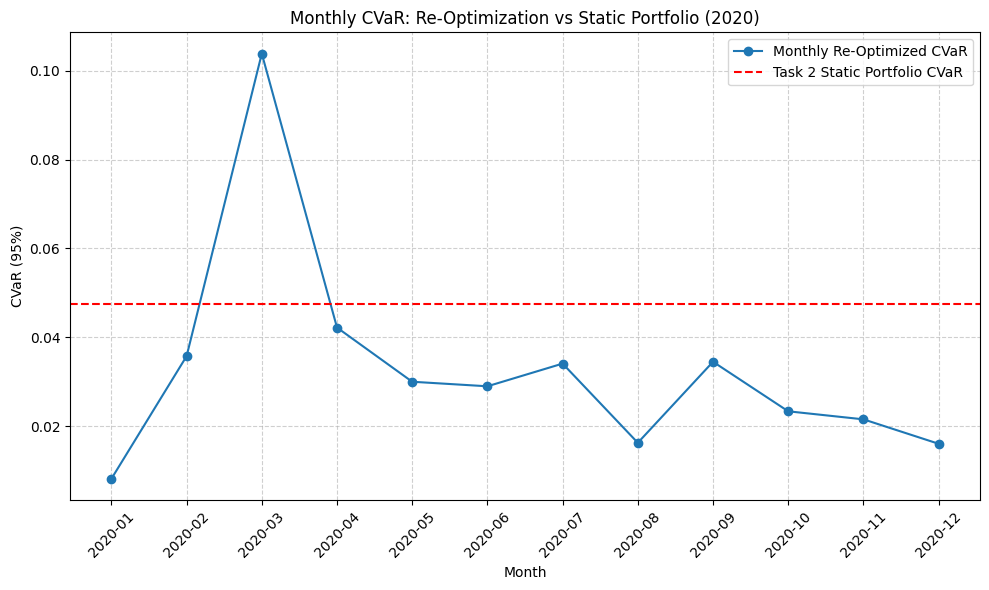

In [33]:
import matplotlib.pyplot as plt

# Plot realized monthly CVaRs
plt.figure(figsize = (10,6))
plt.plot(monthly_cvar_results.keys(), monthly_cvar_results.values(), marker = 'o', label = "Monthly Re-Optimized CVaR")

# static portfolio CVaR as a horizontal line
plt.axhline(y = cvar_2020, color = 'red', linestyle = '--', label = "Task 2 Static Portfolio CVaR")

plt.xticks(rotation = 45)
plt.xlabel("Month")
plt.ylabel("CVaR (95%)")
plt.title("Monthly CVaR: Re-Optimization vs Static Portfolio (2020)")
plt.legend()
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.tight_layout()
plt.show()


### Task 6

A stable portfolio is defined as a monthly allocation such that, for each instrument, the change in
portfolio weight from one month to the next is no more than 5 percentage points (0.05 in weight). Is the
sequence of monthly portfolios you found stable? If it is not stable, you do not need to solve a new
optimization model. Instead, describe how you might add constraints to the CVaR optimization model to
enforce stability in portfolio weights over time

#### Compare with Task 2 and line plot

#### Weight change from one month to the next no more than 5%

In [34]:
import numpy as np

def check_portfolio_stability(monthly_optimal_weights, threshold=0.05):

  # Ensure the monthly keys are in chronological order
  months_sorted = sorted(monthly_optimal_weights.keys())

  stable = True
  for i in range(len(months_sorted) - 1):
      m1, m2 = months_sorted[i], months_sorted[i+1]

      w1 = np.array(monthly_optimal_weights[m1])
      w2 = np.array(monthly_optimal_weights[m2])

      diff = np.abs(w2 - w1)

      if np.any(diff > 0.05):  # change greater than 5 percentage points
            stable = False
            break

  print("Is the portfolio sequence stable:", stable)

check_portfolio_stability(monthly_optimal_weights, threshold=0.05)

Is the portfolio sequence stable: False


In [ ]:
# === Testing Instructions for Task 6 ===
# Output: A boolean value indicating whether the portfolio sequence is stable (True or False).
# How to test:
# 1. Ensure 'monthly_optimal_weights' is available from Task 5
# 2. Execute the above cell.
# 3. Verify the printed output shows "Is the portfolio sequence stable:" followed by True or False.
# 4. You can modify the 'threshold' parameter in the function call to check stability against a different limit.

# Example Call (uncomment to run):
# Assuming monthly_optimal_weights is defined:
# is_stable = check_portfolio_stability(monthly_optimal_weights)
# print("Is the portfolio sequence stable:", is_stable)

**If it is not stable, you do not need to solve a new
optimization model. Instead, describe how you might add constraints to the CVaR optimization model to
enforce stability in portfolio weights over time.**

Looking at the line plot from task 5, we can see that between February to March and March to April there is a big jump in the monthly CVaR, much larger than the 5% threshold.

To enforce that no assets weights move no more than 5% month to month, we can add another linear constraint dictating that:

$$
-0.05 \;\leq\; w_{i,t+1} - w_{i,t} \;\leq\; 0.05
$$

Otherwise, we could introduce slack variables into the contraints, splitting the above constraint into two:

$$
\begin{aligned}
w_{i,t+1} - w_{i,t} &\le 0.05 + s^+_{i,t},\\[6pt]
w_{i,t} - w_{i,t+1} &\le 0.05 + s^-_{i,t},\\[6pt]
s^+_{i,t},\; s^-_{i,t} &\ge 0.
\end{aligned}
$$